In [ ]:
!pip install xgboost

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import os
os.makedirs("outputs", exist_ok=True)

In [ ]:
# Update path if needed
df = pd.read_csv("/kaggle/input/datasets/nikhileshiyer5/marketing-and-product-assignment/marketing_and_product_performance.csv")

print("Shape:", df.shape)
df.head()

In [ ]:
df.info()
df.describe()

# Check missing values
df.isnull().sum()

In [ ]:
target = "Units_Sold"

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

# Impute missing values
imputer_num = SimpleImputer(strategy="mean")
df[num_cols] = imputer_num.fit_transform(df[num_cols])

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical variables
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
X = df.drop(columns=[target])
y = df[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    return [name, mae, rmse, r2]

In [18]:
model = RandomForestRegressor()

scores = cross_val_score(model, X_scaled, y, cv=5, scoring="r2")

df_rq6 = pd.DataFrame({
    "Fold": range(1, 6),
    "R2": scores
})

df_rq6

,Fold,R2
0,1,-0.015293
1,2,-0.023115
2,3,-0.030395
3,4,-0.014627
4,5,-0.036751


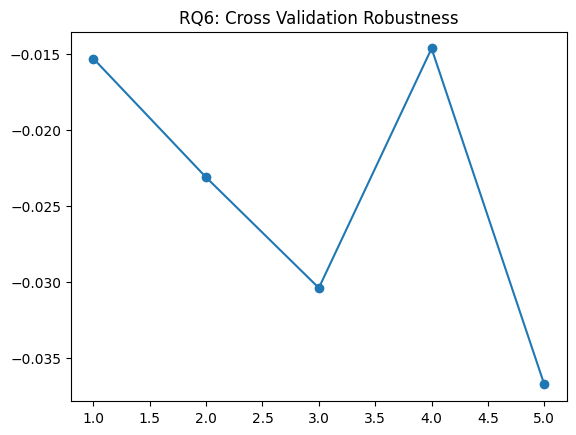

In [19]:
df_rq6.to_csv("outputs/RQ6_robustness.csv", index=False)

plt.plot(df_rq6["Fold"], df_rq6["R2"], marker="o")
plt.title("RQ6: Cross Validation Robustness")
plt.savefig("outputs/RQ6_plot.pdf")
plt.show()